<a href="https://colab.research.google.com/github/Bukasker/MK/blob/main/zad5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Dla wariantu 6 (k = 60%):
-> Wymagana liczba twarzy własnych (r): 8
-> Zachowana informacja: 62.02%


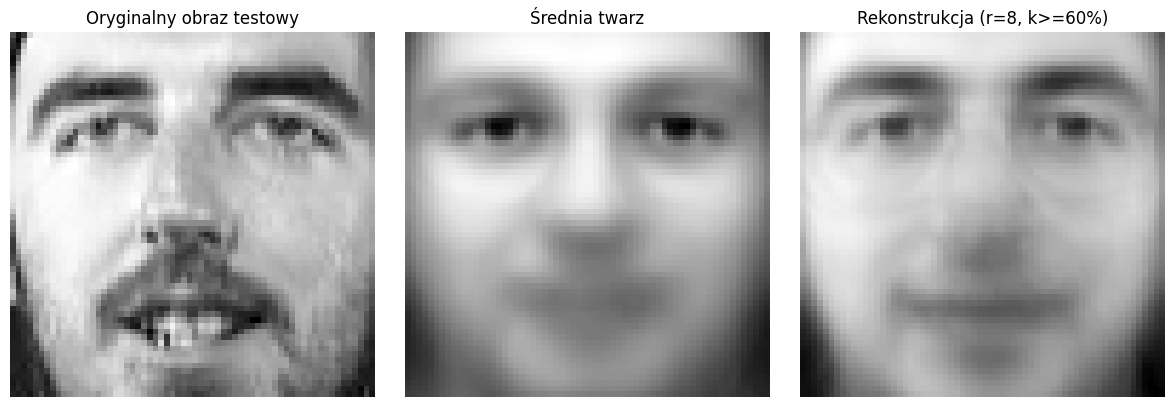

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# 1. Ładowanie przykładowych danych (twarzy)
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
data = faces.data  # Macierz gdzie każdy wiersz to obraz spłaszczony do wektora
images = faces.images
n_samples, n_features = data.shape
height, width = images[0].shape

# Podział na dane treningowe i jeden obraz testowy
X_train = data[:-1].T  # Obrazy jako kolumny (zgodnie z Fig. 1)
x_test = data[-1].reshape(-1, 1)  # Ostatnia twarz jako obraz testowy

# --- KROK 1 & 2: Obliczenie średniej twarzy i odjęcie jej ---
mean_face = np.mean(X_train, axis=1, keepdims=True)
X_centered = X_train - mean_face

# --- KROK 3 & 4: SVD macierzy uśrednionej (PCA) ---
# Używamy econ=True (w numpy: full_matrices=False) dla wydajności
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# --- KROK 5: Wybór liczby r dla wariantu 6 (k = 60%) ---
# Informacja (energia) jest proporcjonalna do kwadratów wartości osobliwych
energy_total = np.sum(S**2)
variance_explained = np.cumsum(S**2) / energy_total

target_k = 0.60  # Wariant 6 = 60% informacji
r = np.argmax(variance_explained >= target_k) + 1

print(f"Dla wariantu 6 (k = 60%):")
print(f"-> Wymagana liczba twarzy własnych (r): {r}")
print(f"-> Zachowana informacja: {variance_explained[r-1]*100:.2f}%")

# --- KROK 6: Przybliżenie obrazu testowego ---
# Odjmujemy średnią twarz od obrazu testowego
x_test_centered = x_test - mean_face

# Macierz U_tilde obcięta do 'r' kolumn
U_tilde = U[:, :r]

# Rekonstrukcja według wzoru: x_test_tilde = U_tilde * U_tilde^T * x_test_centered
x_test_reconstructed_centered = U_tilde @ (U_tilde.T @ x_test_centered)

# Dodajemy z powrotem średnią twarz, aby uzyskać finalny obraz
x_test_reconstructed = x_test_reconstructed_centered + mean_face

# --- WIZUALIZACJA WYNIKÓW ---
plt.figure(figsize=(12, 4))

# Oryginalny obraz
plt.subplot(1, 3, 1)
plt.imshow(x_test.reshape(height, width), cmap='gray')
plt.title("Oryginalny obraz testowy")
plt.axis('off')

# Średnia twarz
plt.subplot(1, 3, 2)
plt.imshow(mean_face.reshape(height, width), cmap='gray')
plt.title("Średnia twarz")
plt.axis('off')

# Zrekonstruowany obraz
plt.subplot(1, 3, 3)
plt.imshow(x_test_reconstructed.reshape(height, width), cmap='gray')
plt.title(f"Rekonstrukcja (r={r}, k>=60%)")
plt.axis('off')

plt.tight_layout()
plt.show()